# Royal Caribbean — Pricing Optimization (Ablation: no `competitor_price`)

**Hypothesis:** the correlation heatmap from the main notebook showed `competitor_price` ≈ `price` — almost a copy of the target. If true, the headline metrics (R² 0.99, MAPE 4%) would be inflated by a feature that barely lags reality. We re-run the pipeline with `competitor_price` removed to see how much of the signal comes from genuinely upstream features (cabin, route, lead time, lags, occupancy).

**What changes vs. the main notebook:** only the `TemporalSplitter`'s `drop_cols` — we add `competitor_price`. Everything else (loading, EDA, feature engineering, models, evaluation, viz) is the **same modules**, called the same way.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd

from src import (
    DataLoader,
    FeatureEngineer,
    TemporalSplitter,
    ModelZoo,
    ModelTrainer,
    Evaluator,
    ResultsVisualizer,
)

## 1. Load and engineer features (identical to the main notebook)

In [3]:
df = DataLoader(PROJECT_ROOT / "data" / "bookings.csv").load()
df_features = FeatureEngineer().transform(df)
df_features.shape

(5000, 28)

## 2. Split — drop `competitor_price` from the feature set

The only line that differs from the main notebook.

In [4]:
splitter = TemporalSplitter(
    train_months=12, val_months=3, target="price",
    drop_cols=("booking_date", "sail_date", "revenue", "competitor_price"),
)
split = splitter.split(df_features)

assert "competitor_price" not in split.feature_cols, "competitor_price should be excluded"
print(f"feature count: {len(split.feature_cols)} (main notebook had +1 for competitor_price)")
split.shapes()

feature count: 23 (main notebook had +1 for competitor_price)


{'train': (3302, 23), 'val': (874, 23), 'test': (824, 23)}

## 3. Train, evaluate, pick winner

In [5]:
trainer = ModelTrainer(ModelZoo.default_models())
trainer.fit(split.X_train, split.y_train)

trained: LinearRegression


trained: RandomForest


trained: XGBoost


trained: GradientBoosting


{'LinearRegression': LinearRegression(),
 'RandomForest': RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42),
 'XGBoost': XGBRegressor(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=400,
              n_jobs=-1, num_parallel_tree=None, ...),
 'GradientBoosting': GradientBoostingRegressor(learning_rate=0.05, n_estimators=300, random_state=42)}

In [6]:
evaluator = Evaluator()
leaderboard = evaluator.evaluate_all(trainer.predict(split.X_val), split.y_val)
leaderboard

,RMSE,MAPE,R2
GradientBoosting,91.221515,0.067811,0.975848
RandomForest,93.194063,0.069472,0.974792
XGBoost,95.746543,0.071177,0.973392
LinearRegression,117.924646,0.104633,0.959638


In [7]:
winner_name, wins = evaluator.select_winner(leaderboard)
print("Wins per metric:")
print(wins)
print(f"\nWinner (no competitor_price): {winner_name}")
winner_model = trainer.get(winner_name)

Wins per metric:
                   RMSE   MAPE     R2  total_wins
GradientBoosting   True   True   True           3
RandomForest      False  False  False           0
XGBoost           False  False  False           0
LinearRegression  False  False  False           0

Winner (no competitor_price): GradientBoosting


## 4. Test-set performance

In [8]:
test_metrics = evaluator.score(split.y_test, winner_model.predict(split.X_test))
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}")

RMSE: 93.6418
MAPE: 0.0654
R2: 0.9765


## 5. Side-by-side vs. the main notebook

Reference values from `pricing_optimization.ipynb` (winner: GradientBoosting, with `competitor_price` included):

- RMSE: 65.4968
- MAPE: 0.0418
- R²:   0.9885

In [9]:
baseline = {"RMSE": 65.4968, "MAPE": 0.0418, "R2": 0.9885}
comparison = pd.DataFrame({
    "with_competitor_price": baseline,
    "without_competitor_price": test_metrics,
}).T
comparison["Δ_RMSE"] = comparison["RMSE"] - comparison.loc["with_competitor_price", "RMSE"]
comparison["Δ_R2"] = comparison["R2"] - comparison.loc["with_competitor_price", "R2"]
comparison

,RMSE,MAPE,R2,Δ_RMSE,Δ_R2
with_competitor_price,65.496800,0.041800,0.988500,0.000000,0.000000
without_competitor_price,93.641788,0.065402,0.976485,28.144988,-0.012015


## 6. Diagnostics on the new winner

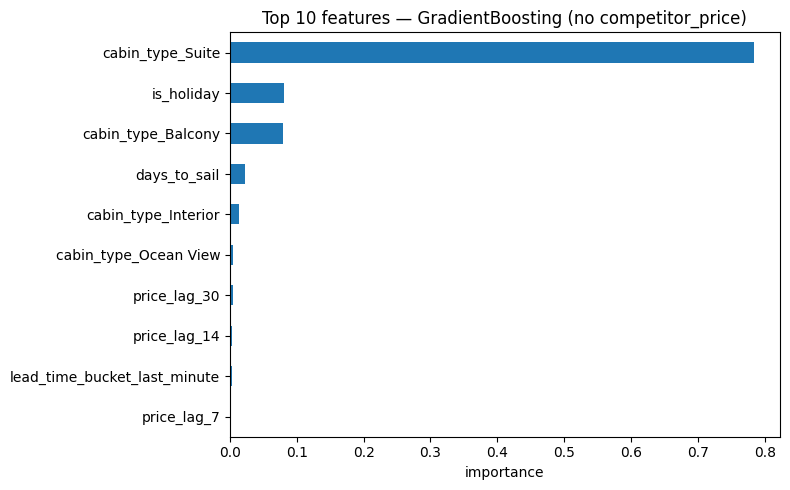

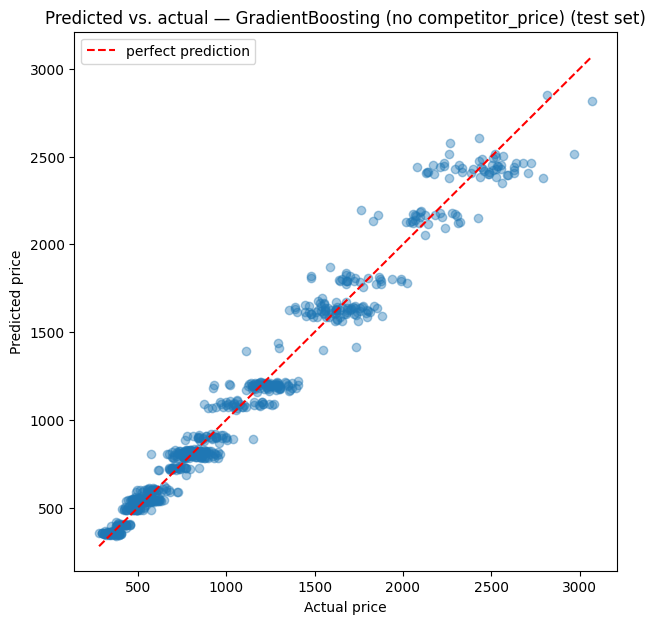

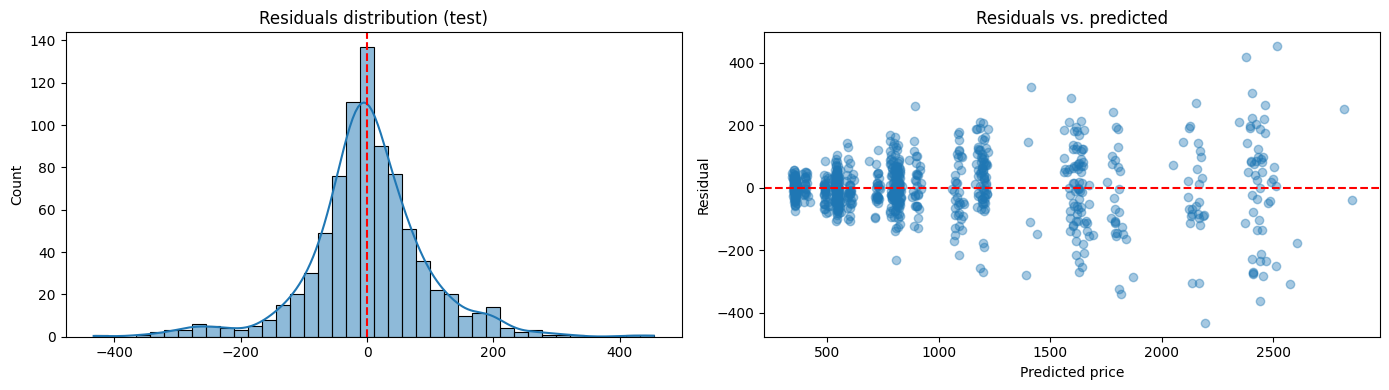

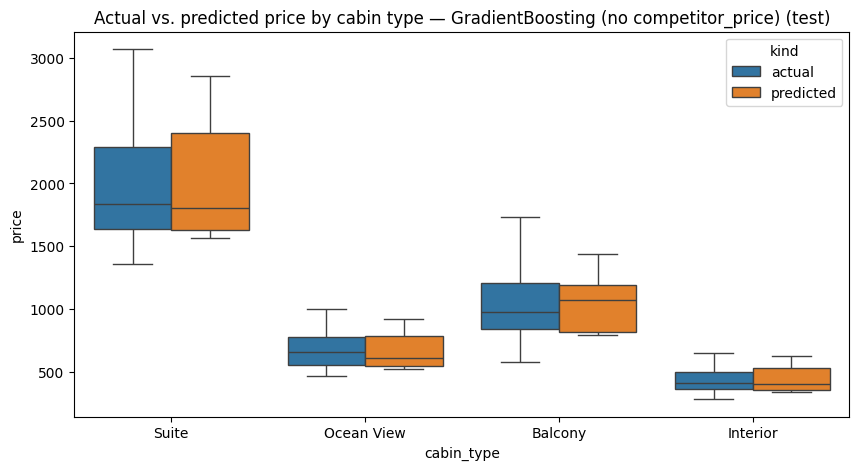

cabin_type_Suite                0.783622
is_holiday                      0.081150
cabin_type_Balcony              0.079844
days_to_sail                    0.021964
cabin_type_Interior             0.013465
cabin_type_Ocean View           0.005231
price_lag_30                    0.004088
price_lag_14                    0.003833
lead_time_bucket_last_minute    0.002753
price_lag_7                     0.002287
dtype: float64

In [10]:
viz = ResultsVisualizer(
    model=winner_model,
    model_name=f"{winner_name} (no competitor_price)",
    X_test=split.X_test,
    y_test=split.y_test,
    df_test_encoded=df_features.loc[split.test_mask],
)
top10 = viz.run_all(top_n=10)
top10

## Read the result

- If RMSE/MAPE jump and R² drops sharply → `competitor_price` was carrying most of the model and the original headline numbers were misleading. The honest baseline for the pricing team is *this* notebook's number.
- If the metrics barely move → the lag features and cabin/route signals are doing the real work, and `competitor_price` was redundant rather than dominant. Either way, removing it is good for production: one less external feed to maintain.
- The new top-10 feature importance plot is the most useful artifact: it shows which signals the model leans on once the near-copy of the target is removed.